# Climate-Alpha: Quantitative ESG Trading Platform
## Complete Demonstration Notebook

This notebook demonstrates all components of the Climate-Alpha platform:
1. Data Collection
2. Feature Engineering
3. LSTM Price Prediction
4. Pairs Trading Strategy
5. Portfolio Optimization
6. Risk Management

In [22]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from backend.data.collectors import DataCollector
from backend.data.features import FeatureEngineer
from backend.models.lstm_predictor import LSTMPredictor
from backend.strategies.pairs_trading import PairsTradingStrategy
from backend.risk.portfolio_opt import PortfolioOptimizer
from backend.risk.var_calculator import RiskCalculator
from backend.utils.metrics import PerformanceMetrics

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ All modules imported successfully")

✓ All modules imported successfully


## 1. Data Collection

In [23]:
# Initialize data collector
collector = DataCollector()

# Download full universe
print("Downloading market data...")
data = collector.download_full_universe(
    start_date="2019-01-01",
    end_date="2024-12-31"
)

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nTickers: {data.columns.get_level_values(0).unique().tolist()}")

2026-03-07 00:25:17 - climate_alpha - INFO - download_full_universe:249 - Downloading full universe: 32 tickers
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:54 - Downloading data for 32 tickers from 2019-01-01 to 2024-12-31
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:60 - Downloading ICLN...
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:71 - ✓ ICLN: 1509 rows
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:60 - Downloading TAN...
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:71 - ✓ TAN: 1509 rows


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 70: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\application.py", line 107

2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:60 - Downloading QCLN...
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:71 - ✓ QCLN: 1509 rows
2026-03-07 00:25:17 - climate_alpha - INFO - download_stock_data:60 - Downloading PBW...


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 70: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\application.py", line 107

2026-03-07 00:25:18 - climate_alpha - INFO - download_stock_data:71 - ✓ PBW: 1509 rows
2026-03-07 00:25:18 - climate_alpha - INFO - download_stock_data:60 - Downloading FAN...
2026-03-07 00:25:18 - climate_alpha - INFO - download_stock_data:71 - ✓ FAN: 1509 rows


...

2026-03-07 00:25:22 - climate_alpha - INFO - download_stock_data:60 - Downloading TLT...
2026-03-07 00:25:22 - climate_alpha - INFO - download_stock_data:71 - ✓ TLT: 1509 rows


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 70: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\application.py", line 107

2026-03-07 00:25:22 - climate_alpha - INFO - download_stock_data:60 - Downloading GLD...
2026-03-07 00:25:22 - climate_alpha - INFO - download_stock_data:71 - ✓ GLD: 1509 rows


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 70: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\diksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\traitlets\config\application.py", line 107

2026-03-07 00:25:23 - climate_alpha - INFO - download_stock_data:90 - Saved data to data\raw\market_data_2019-01-01_2024-12-31.csv

Data shape: (1509, 155)
Date range: 2019-01-02 00:00:00 to 2024-12-30 00:00:00

Tickers: ['ICLN', 'TAN', 'QCLN', 'PBW', 'FAN', 'ACES', 'ENPH', 'SEDG', 'FSLR', 'RUN', 'NEE', 'BEP', 'PLUG', 'BE', 'ARRY', 'XLE', 'XOP', 'IEO', 'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC', 'PSX', 'VLO', 'OXY', 'HAL', 'SPY', 'TLT', 'GLD']


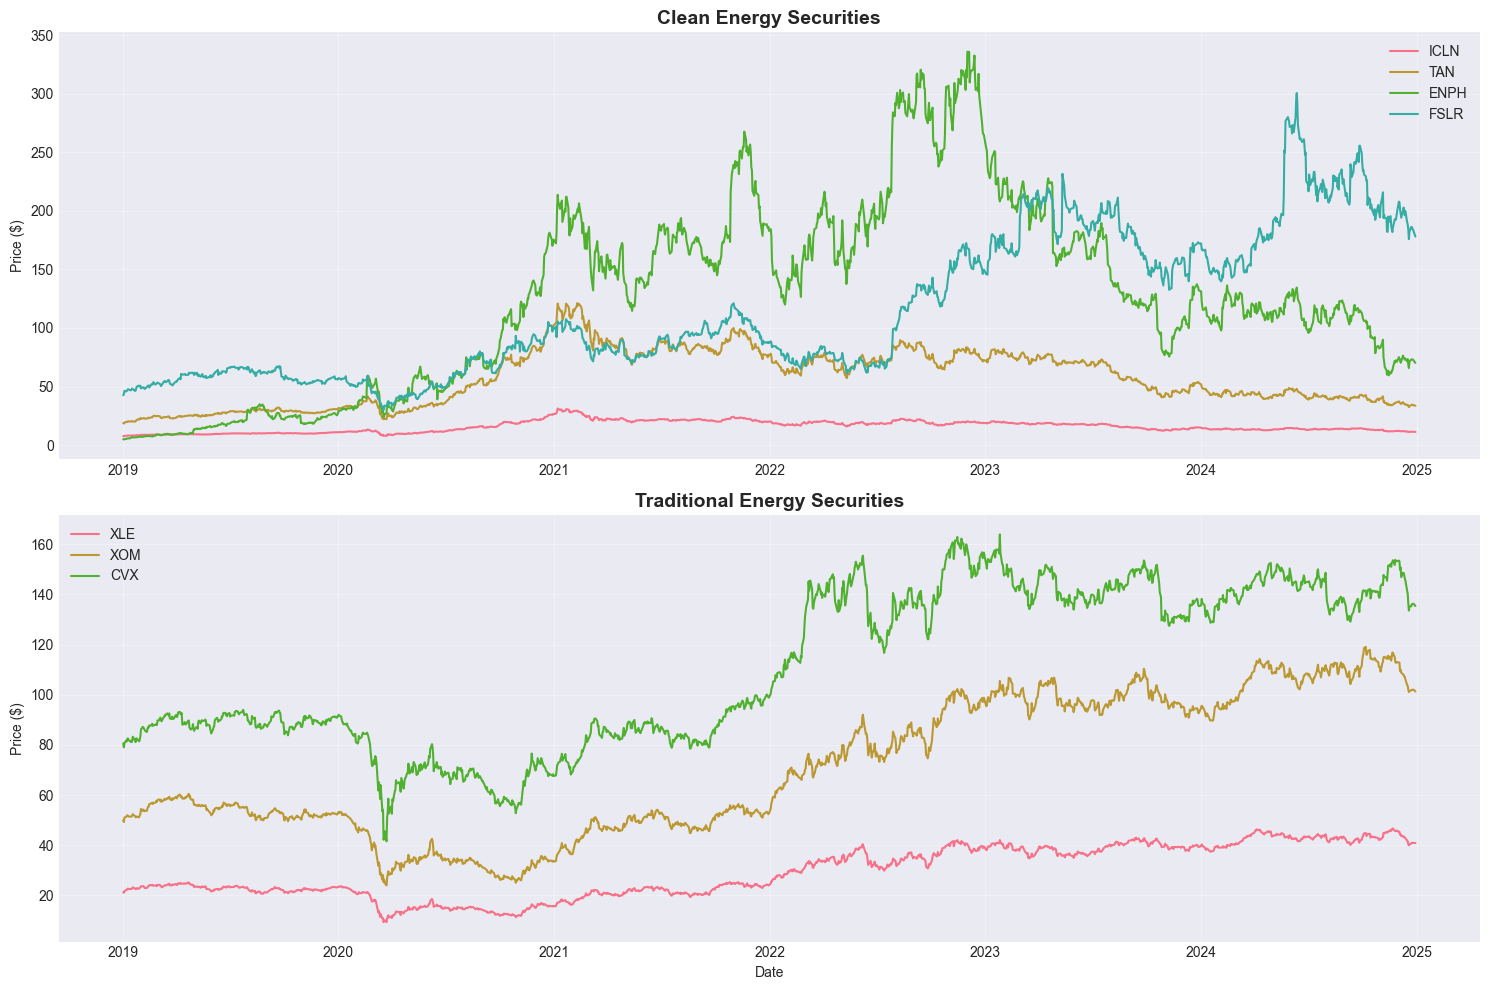

In [24]:
# Extract closing prices
close_prices = data.xs('Close', axis=1, level=1)

# Plot price evolution
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Clean energy
clean_tickers = ['ICLN', 'TAN', 'ENPH', 'FSLR']
for ticker in clean_tickers:
    if ticker in close_prices.columns:
        axes[0].plot(close_prices.index, close_prices[ticker], label=ticker)
axes[0].set_title('Clean Energy Securities', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Traditional energy
traditional_tickers = ['XLE', 'XOM', 'CVX']
for ticker in traditional_tickers:
    if ticker in close_prices.columns:
        axes[1].plot(close_prices.index, close_prices[ticker], label=ticker)
axes[1].set_title('Traditional Energy Securities', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [25]:
# Select a ticker for feature engineering demo
ticker = 'ICLN'
ticker_data = data[ticker].copy()

# Initialize feature engineer
engineer = FeatureEngineer()

# Create complete feature set
features = engineer.create_feature_set(
    ticker_data,
    technical=True,
    price=True,
    volume=True,
    volatility=True,
    momentum=True,
    time=True
)

print(f"Original columns: {len(ticker_data.columns)}")
print(f"Feature columns: {len(features.columns)}")
print(f"\nFeature list (first 20):")
print(features.columns.tolist()[:20])

2026-03-07 00:25:24 - climate_alpha - INFO - add_technical_features:29 - Adding technical features...


ValueError: Data must be 1-dimensional, got ndarray of shape (1509, 1) instead

## 3. LSTM Price Prediction

In [ ]:
# Prepare data for LSTM
predictor = LSTMPredictor(lookback_days=60, lstm_units=[128, 64, 32])

# Use Close price and a few key features
feature_cols = ['Close', 'sma_20', 'rsi_14', 'macd', 'obv']
X, y = predictor.prepare_data(features, target_col='Close', feature_cols=feature_cols)

# Split train/test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

In [ ]:
# Train LSTM model
history = predictor.train(
    X_train, y_train,
    X_test, y_test,
    epochs=50,
    batch_size=32,
    verbose=1
)

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model
metrics = predictor.evaluate(X_test, y_test)
print("\nModel Performance:")
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")

## 4. Pairs Trading Strategy

In [ ]:
# Initialize pairs trading strategy
pairs_strategy = PairsTradingStrategy(
    lookback_period=252,
    entry_zscore=2.0,
    exit_zscore=0.5
)

# Find cointegrated pairs
pairs = pairs_strategy.find_cointegrated_pairs(close_prices)

print(f"\nFound {len(pairs)} cointegrated pairs:")
for ticker1, ticker2, p_value in pairs[:5]:
    print(f"  {ticker1} - {ticker2}: p-value = {p_value:.4f}")

In [ ]:
# Backtest best pair
if pairs:
    ticker1, ticker2, _ = pairs[0]
    s1 = close_prices[ticker1]
    s2 = close_prices[ticker2]
    
    results = pairs_strategy.backtest_pair(s1, s2, initial_capital=100000)
    
    print(f"\n{'='*60}")
    print(f"PAIRS TRADING BACKTEST: {ticker1} - {ticker2}")
    print(f"{'='*60}")
    print(f"Total Return:        {results['total_return']:>10.2%}")
    print(f"Annual Return:       {results['annual_return']:>10.2%}")
    print(f"Annual Volatility:   {results['annual_volatility']:>10.2%}")
    print(f"Sharpe Ratio:        {results['sharpe_ratio']:>10.2f}")
    print(f"Max Drawdown:        {results['max_drawdown']:>10.2%}")
    print(f"Win Rate:            {results['win_rate']:>10.2%}")
    print(f"Number of Trades:    {results['num_trades']:>10.0f}")
    print(f"{'='*60}")

## 5. Portfolio Optimization

In [ ]:
# Select clean energy universe for portfolio
portfolio_tickers = ['ICLN', 'TAN', 'ENPH', 'FSLR', 'NEE']
portfolio_prices = close_prices[portfolio_tickers].dropna()
portfolio_returns = portfolio_prices.pct_change().dropna()

# Initialize optimizer
optimizer = PortfolioOptimizer(risk_free_rate=0.02)

# Mean-Variance Optimization
mv_result = optimizer.mean_variance_optimization(portfolio_returns)

print("\nMean-Variance Optimal Portfolio:")
print(mv_result['weights'])
print(f"\nExpected Return: {mv_result['expected_return']:.2%}")
print(f"Volatility: {mv_result['volatility']:.2%}")
print(f"Sharpe Ratio: {mv_result['sharpe_ratio']:.2f}")

In [ ]:
# Risk Parity Optimization
rp_result = optimizer.risk_parity_optimization(portfolio_returns)

print("\nRisk Parity Portfolio:")
print(rp_result['weights'])
print(f"\nExpected Return: {rp_result['expected_return']:.2%}")
print(f"Volatility: {rp_result['volatility']:.2%}")
print(f"Sharpe Ratio: {rp_result['sharpe_ratio']:.2f}")

In [ ]:
# ESG-Constrained Optimization
esg_scores = pd.Series({
    'ICLN': 8.5,
    'TAN': 8.0,
    'ENPH': 7.5,
    'FSLR': 8.2,
    'NEE': 9.0
})

esg_result = optimizer.esg_constrained_optimization(
    portfolio_returns,
    esg_scores,
    min_esg_score=7.5
)

print("\nESG-Constrained Portfolio:")
print(esg_result['weights'])
print(f"\nExpected Return: {esg_result['expected_return']:.2%}")
print(f"Volatility: {esg_result['volatility']:.2%}")
print(f"Sharpe Ratio: {esg_result['sharpe_ratio']:.2f}")
print(f"ESG Score: {esg_result['esg_score']:.1f}")

## 6. Risk Management

In [ ]:
# Initialize risk calculator
risk_calc = RiskCalculator()

# Use ICLN returns for risk analysis
icln_returns = portfolio_returns['ICLN']

# Generate comprehensive risk report
risk_report = risk_calc.comprehensive_risk_report(
    icln_returns,
    portfolio_value=1000000
)

risk_calc.print_risk_report(risk_report)

In [ ]:
# Stress Testing
scenarios = {
    '2008 Financial Crisis': -0.35,
    'COVID-19 Pandemic': -0.25,
    'Climate Scenario 2°C': -0.10,
    'Climate Scenario 3°C': -0.20,
    'Climate Scenario 4°C': -0.30,
    'Carbon Tax Implementation': -0.15
}

stress_results = risk_calc.stress_test(
    icln_returns,
    portfolio_value=1000000,
    scenarios=scenarios
)

print("\nStress Test Results:")
print(stress_results.to_string(index=False))

## 7. Performance Summary

In [ ]:
# Calculate performance metrics for the portfolio
benchmark_returns = close_prices['SPY'].pct_change().dropna()

metrics_calc = PerformanceMetrics(
    returns=icln_returns,
    benchmark_returns=benchmark_returns,
    risk_free_rate=0.02
)

metrics_calc.print_summary()

## Conclusion

This notebook demonstrated:
- ✅ Data collection and processing
- ✅ Feature engineering with 100+ technical indicators
- ✅ LSTM deep learning for price prediction
- ✅ Pairs trading with cointegration analysis
- ✅ Portfolio optimization (Mean-Variance, Risk Parity, ESG-constrained)
- ✅ Comprehensive risk management (VaR, CVaR, stress testing)

This platform addresses **UN SDG 13 (Climate Action)** and **SDG 7 (Affordable Clean Energy)** while demonstrating advanced quantitative finance skills.